<a href="https://colab.research.google.com/github/fvaselli/NP_Twins/blob/main/02_conditional_flow_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧲 Notebook 2 — Conditional Flow Matching on CMS Jet Data

**Duration:** ~1.5 hours &nbsp;·&nbsp; **Prerequisites:** Notebook 1 (Flow Matching fundamentals)

In Notebook 1 you built Flow Matching from scratch on 2D toy data. Now we flip a single switch — **conditioning** — and suddenly the same machinery becomes a surrogate for expensive detector simulation at the LHC. 🎯

### 🎬 The physics problem, in one paragraph

At the CMS experiment, simulating the detector response for a single event costs minutes of CPU time per event. A neural **conditional generator** that learns

$$p(\mathbf{x}_{\text{reco}} \mid \mathbf{x}_{\text{gen}})$$

— the distribution of *reconstructed* jet features given *generator-level* jet features — can replace that Monte Carlo with a forward pass of a neural network. Orders of magnitude faster. We call the result a **fast detector simulator** (a.k.a. "twin", "FLASH", "Delphes-with-ML").

### 🎯 What you'll walk away with

1. A concrete **data pipeline** for CMS jet pairs (gen, reco), with preprocessing handled for you 🧼
2. A **sinusoidal time embedding** that gives the network a richer notion of "where in the flow" it is ⏱️
3. A **`ConditionalVectorField`** network — MLP + residual blocks + conditioning — built from scratch 🧠
4. A **conditional CFM loss** + training loop that produces a real, working fast simulator in under 5 minutes 🏋️
5. A sanity-check **WOW cell** that shows concretely *why* conditioning matters (compared to an unconditional baseline) 🎇

### 🧪 How this notebook is structured

Same style as NB1:

- Each section introduces a concept, then asks you to implement a building block (`Task X.Y`).
- Right after each task, a cell calls a function from `test_conditional_flow.py` — run it to validate before moving on! ✅
- At the end, `run_all_tests_nb2(...)` checks everything together, then we train on real CMS data.

The solution notebook `02_conditional_flow_model_solution.ipynb` is in the same folder — resist peeking until you've tried. 💪

### 📚 Symbols

| Symbol | Meaning |
|---|---|
| 🎯 | Goal of the section |
| ✏️ | Task to implement |
| 💡 | Hint |
| ⚠️ | Common pitfall |
| 🧪 | Validation cell |
| 🚀 | Let's run it! |
| 🎁 | Provided for you (just run) |


## ⚙️ Setup

> **Running on Google Colab?** Run the install cell below — it's a no-op on machines where the packages are already installed, and it also downloads the dataset and the test suite.
> **Running locally?** Activate your tutorial env (see `README.md`), then download `data.npy` into this folder (see the command in the next cell).

In [31]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'torch', 'numpy', 'scipy', 'scikit-learn',
                           'matplotlib', 'torchdiffeq'])
    # Download the test suite
    import urllib.request
    if not os.path.exists('test_conditional_flow.py'):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/fvaselli/NP_Twins/main/test_conditional_flow.py',
            'test_conditional_flow.py',
        )
    # Download the utils (for plotting)
    if not os.path.exists('utils.py'):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/fvaselli/NP_Twins/main/utils.py',
            'utils.py',
        )
    print('✅ Colab environment ready.')
else:
    print('✅ Local environment — skipping install.')

# Download the dataset if not present (≈ 150 MB)
if not os.path.exists('data.npy'):
    print('📥 Downloading CMS jet dataset from Zenodo (~150 MB, one-off)...')
    import urllib.request
    urllib.request.urlretrieve(
        'https://zenodo.org/records/11126625/files/gen_ttbar_400k_final.npy',
        'data.npy',
    )
    print('✅ Dataset downloaded.')
else:
    print('✅ data.npy already present.')


✅ Local environment — skipping install.
✅ data.npy already present.


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


We import the NB2 test suite — run the `test_*` calls that follow each task, and `run_all_tests_nb2(...)` at the very end.

In [33]:
from test_conditional_flow import (
    test_sinusoidal_embedding,
    test_conditional_vector_field_model,
    test_conditional_fm_loss,
    test_train_conditional_model,
    test_generate_reco,
    run_all_tests_nb2,
)


## 1. The CMS Jet Dataset 🥽

The dataset is a NumPy array of 400k top-pair events, each row representing **one jet** with both its **generator-level** truth features (what nature produced) and its **reconstruction-level** measured features (what the detector saw).

**Reco features** (what the detector measures):
| Col | Name | Meaning |
|---|---|---|
| 0 | `btag` | b-tagging discriminator score (continuous, roughly ∈ [0, 1]) |
| 1 | `pt` | transverse momentum [GeV] |
| 2 | `phi` | azimuthal angle [rad] |
| 3 | `eta` | pseudorapidity |
| 4 | `N_const` | number of constituents (integer) |
| 5 | `ctag` | charm-tagging discriminator |

**Gen features** (the "conditions" that drive the generation):
| Col | Name | Meaning |
|---|---|---|
| 0 | `pt` | transverse momentum [GeV] |
| 1 | `eta` | pseudorapidity |
| 2 | `phi` | azimuthal angle [rad] |
| 3 | `E` | energy [GeV] |
| 4 | `flavour` | 0 (light), 1 (charm), 2 (bottom) |
| 5 | `muonsInJet` | number of muons inside the jet |

**We only tackle 3 reco features in this notebook** — `btag`, `pt`, `N_const` — so that training fits in well under 5 minutes on CPU. Notebook 3 scales up to all 6. 🥖


### 🎁 Provided: data loading

Nothing for you to implement here — we give you a `DataExtractor` that slices the right columns and relabels flavour. Just run the cell.

In [34]:
class DataExtractor:
    # Load and extract gen/reco features from the jet dataset.

    def __init__(self, data_path, n_samples=None):
        self.data = np.load(data_path, allow_pickle=True)
        if n_samples is not None:
            self.data = self.data[:n_samples]

        # Reco: btag, pt, phi, eta, N_const, ctag
        self.reco_features = ['btag', 'pt', 'phi', 'eta', 'N_const', 'ctag']
        self.reco = self.data[:, [5, 6, 7, 8, 10, 19]]

        # Gen: pt, eta, phi, E, flavour, muonsInJet
        self.gen_features = ['pt', 'eta', 'phi', 'E', 'flavour', 'muonsInJet']
        self.gen = self.data[:, [0, 1, 2, 3, 4, 9]]

        # Collapse flavour: 0=light, 1=charm, 2=bottom
        flav = np.abs(self.gen[:, 4])
        flav = np.where(np.isin(flav, [1, 2, 3, 21]), 0, flav)  # light + gluons
        flav = np.where(flav == 4, 1, flav)   # charm
        flav = np.where(flav == 5, 2, flav)   # bottom
        self.gen[:, 4] = flav

    def get_reco(self): return self.reco
    def get_gen(self):  return self.gen


extractor = DataExtractor('data.npy', n_samples=400000)
reco_data = extractor.get_reco()
gen_data  = extractor.get_gen()

print(f'Reco data shape: {reco_data.shape}  — features: {extractor.reco_features}')
print(f'Gen data shape:  {gen_data.shape}  — features: {extractor.gen_features}')
print(f'\nFlavour mix: light={np.mean(gen_data[:,4]==0):.1%}, '
      f'charm={np.mean(gen_data[:,4]==1):.1%}, '
      f'bottom={np.mean(gen_data[:,4]==2):.1%}')


Reco data shape: (400000, 6)  — features: ['btag', 'pt', 'phi', 'eta', 'N_const', 'ctag']
Gen data shape:  (400000, 6)  — features: ['pt', 'eta', 'phi', 'E', 'flavour', 'muonsInJet']

Flavour mix: light=56.7%, charm=12.5%, bottom=30.8%


### 🎁 Provided: a peek at the data

Just look at the plots — no coding needed. Notice the **long-tailed `pt` distribution** (challenging for a generator) and the **correlation between reco and gen `pt`** (the single most important thing the model has to learn).

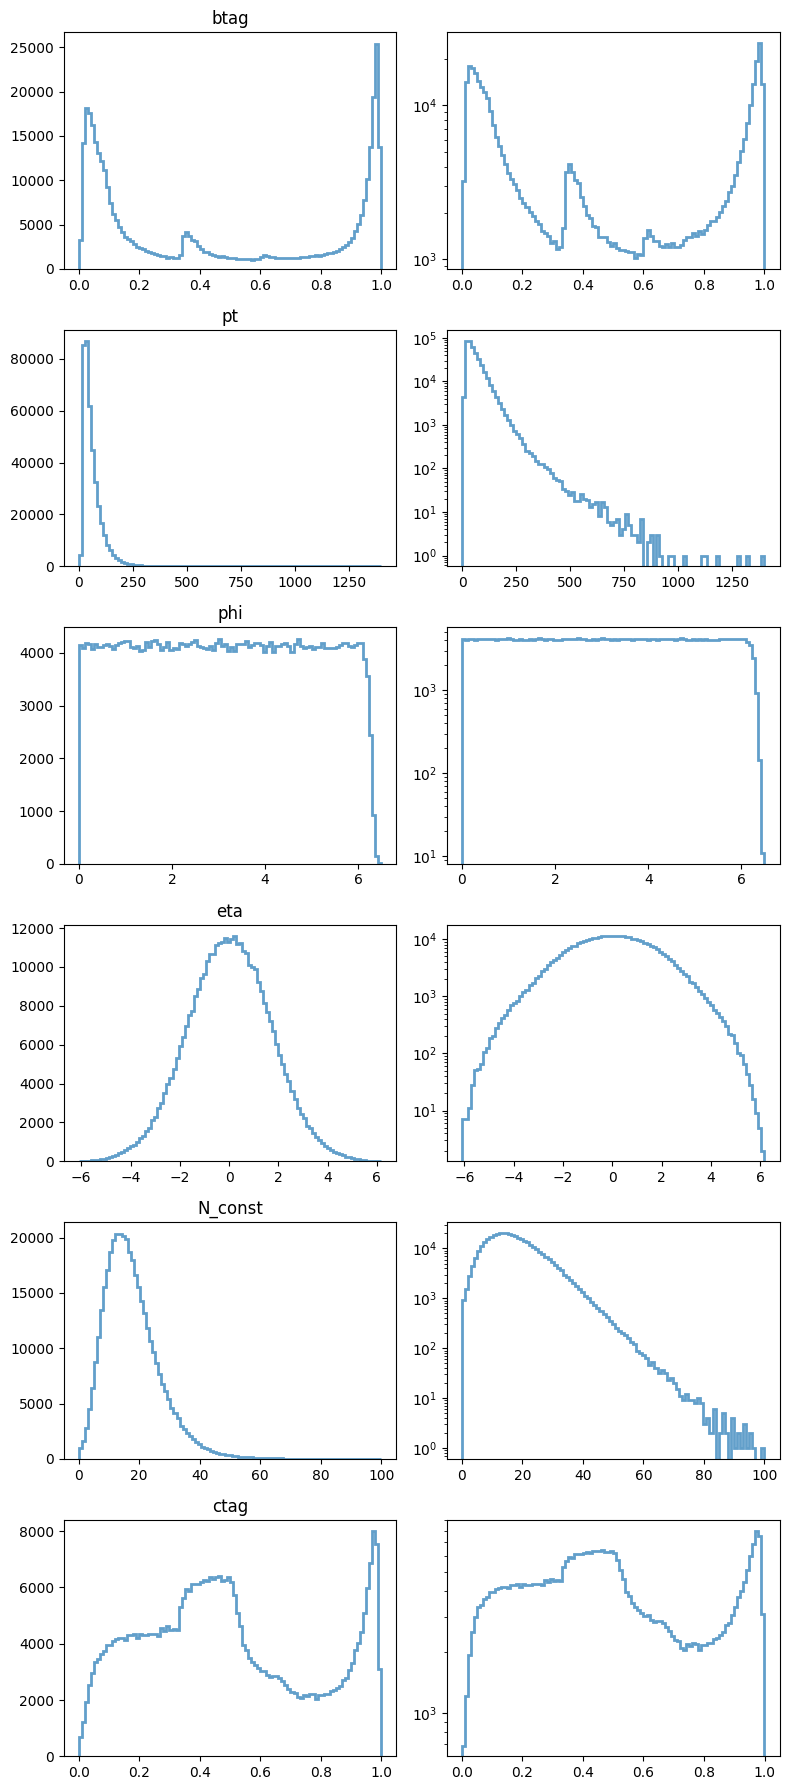

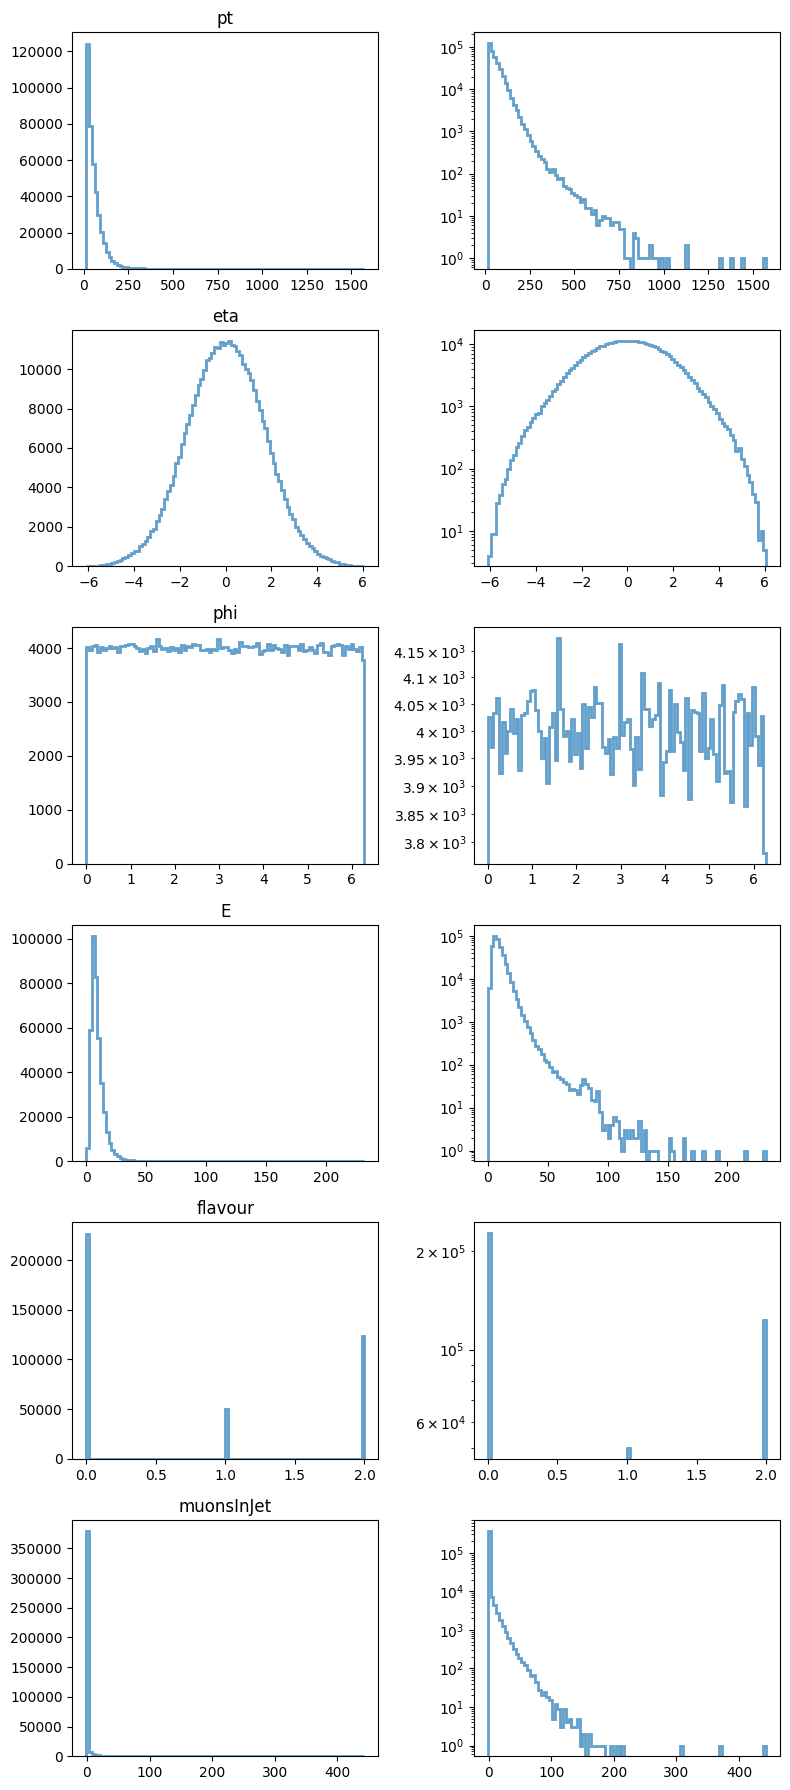

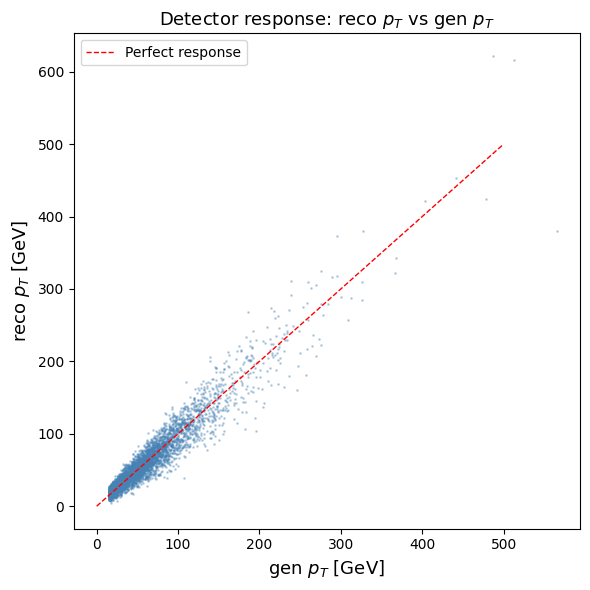

In [35]:
from utils import plot_1dhistos

plot_1dhistos(reco_data, extractor.reco_features)
plot_1dhistos(gen_data, extractor.gen_features)

# Scatter: reco_pt vs gen_pt — the main correlation to learn
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(gen_data[:5000, 0], reco_data[:5000, 1], s=1, alpha=0.3, c='steelblue')
ax.plot([0, 500], [0, 500], 'r--', lw=1, label='Perfect response')
ax.set_xlabel('gen $p_T$ [GeV]', fontsize=13)
ax.set_ylabel('reco $p_T$ [GeV]', fontsize=13)
ax.set_title('Detector response: reco $p_T$ vs gen $p_T$', fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()


## 2. Preprocessing — Provided 🧼

Raw physics features have *wildly* different scales: `pt` ranges from tens to hundreds of GeV, `btag` lives in [0, 1], `N_const` is a small integer. Neural networks hate this. We apply a handful of standard tricks — standardising continuous features, **taking the ratio `reco_pt / gen_pt`** (so the model predicts a *detector correction* rather than absolute momentum), and **dequantising** `N_const` with uniform noise in [−0.5, 0.5] (so a continuous density model can generate a discrete count).

These are all engineering choices a practitioner would make once and hide in a module — so we do exactly that.

> **Why not ask you to implement this?** Because preprocessing is the least interesting part of the pipeline, and getting it subtly wrong silently breaks everything downstream. We'd rather spend your 1.5 h on the model. 🎁


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


class Preprocessor:
    # Preprocess the 3-variable reco target [btag, pt_ratio, N_const].
    # - btag:    standard scale
    # - pt:      compute ratio reco_pt / gen_pt, then standard scale
    # - N_const: dequantise with U[-0.5, 0.5], then standard scale
    # - gen:     standard-scale continuous features (pt, eta, phi, E);
    #            leave flavour + muonsInJet as-is (discrete condition flags).

    def __init__(self):
        self.reco_scaler = StandardScaler()
        self.gen_scaler = StandardScaler()

    def transform(self, reco, gen, fit=False):
        wreco, wgen = np.copy(reco), np.copy(gen)

        btag     = wreco[:, 0]
        pt_ratio = wreco[:, 1] / wgen[:, 0]
        n_const  = wreco[:, 4] + np.random.uniform(-0.5, 0.5, len(wreco))

        reco_3 = np.stack([btag, pt_ratio, n_const], axis=1)

        if fit:
            reco_3 = self.reco_scaler.fit_transform(reco_3)
            wgen[:, :4] = self.gen_scaler.fit_transform(wgen[:, :4])
        else:
            reco_3 = self.reco_scaler.transform(reco_3)
            wgen[:, :4] = self.gen_scaler.transform(wgen[:, :4])
        return reco_3, wgen

    def inverse_transform(self, reco_t, gen_t):
        wreco, wgen = np.copy(reco_t), np.copy(gen_t)
        wreco = self.reco_scaler.inverse_transform(wreco)
        wgen[:, :4] = self.gen_scaler.inverse_transform(wgen[:, :4])

        # pt_ratio → pt  (multiply by gen_pt)
        wreco[:, 1] = wreco[:, 1] * wgen[:, 0]
        # N_const: dequantised → integer count
        wreco[:, 2] = np.rint(wreco[:, 2])
        return wreco, wgen


preprocessor = Preprocessor()

# Split first, then fit the scalers only on training data
reco_tr_raw, reco_vl_raw, gen_tr_raw, gen_vl_raw = train_test_split(
    reco_data, gen_data, test_size=0.2, random_state=42
)
reco_train, gen_train = preprocessor.transform(reco_tr_raw, gen_tr_raw, fit=True)
reco_val,   gen_val   = preprocessor.transform(reco_vl_raw, gen_vl_raw, fit=False)

print(f'Training set:   reco {reco_train.shape}, gen {gen_train.shape}')
print(f'Validation set: reco {reco_val.shape}, gen {gen_val.shape}')
print(f'Reco train stats: mean={reco_train.mean(axis=0).round(2)}, '
      f'std={reco_train.std(axis=0).round(2)}')

# Move to device as tensors
reco_train_t = torch.tensor(reco_train, dtype=torch.float32).to(device)
gen_train_t  = torch.tensor(gen_train,  dtype=torch.float32).to(device)
reco_val_t   = torch.tensor(reco_val,   dtype=torch.float32).to(device)
gen_val_t    = torch.tensor(gen_val,    dtype=torch.float32).to(device)


Training set:   reco (320000, 3), gen (320000, 6)
Validation set: reco (80000, 3), gen (80000, 6)
Reco train stats: mean=[ 0. -0. -0.], std=[1. 1. 1.]


Let's visualise the preprocessed reco targets — these are what the model learns to generate. They should look roughly centred and of unit scale, which is easy territory for a neural network.

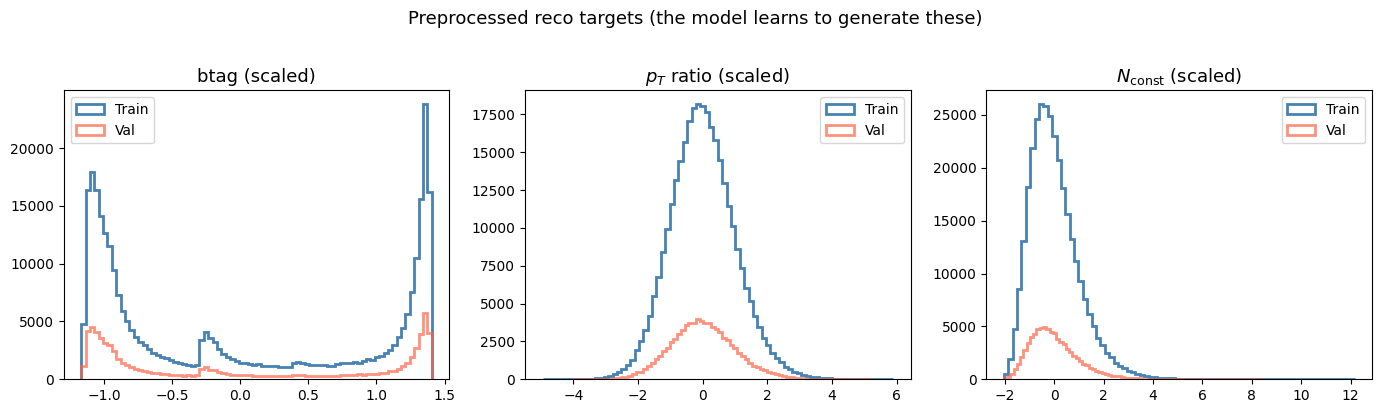

In [37]:
reco_target_names = ['btag (scaled)', r'$p_T$ ratio (scaled)', r'$N_{\mathrm{const}}$ (scaled)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (ax, name) in enumerate(zip(axes, reco_target_names)):
    ax.hist(reco_train[:, i], bins=80, histtype='step', lw=2, color='steelblue', label='Train')
    ax.hist(reco_val[:, i],   bins=80, histtype='step', lw=2, color='tomato', alpha=0.7, label='Val')
    ax.set_title(name, fontsize=13); ax.legend(fontsize=10)
plt.suptitle('Preprocessed reco targets (the model learns to generate these)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 3. Time Embedding ⏱️

In NB1 we fed the time `t` into the network as a single raw scalar. That works, but it's a surprisingly *low-resolution* signal: the network has to squeeze a dense continuous function of `t` through a 1-dim input.

A standard upgrade (borrowed from Transformers) is the **sinusoidal embedding** — map the scalar `t` to a high-dimensional vector using a bank of sines and cosines at geometrically-spaced frequencies:

$$\text{embed}(t)_{2i}   = \sin(t \cdot \omega_i), \qquad \text{embed}(t)_{2i+1} = \cos(t \cdot \omega_i)$$

with $\omega_i = \exp\!\Big(-\frac{i \cdot \ln(10000)}{d/2}\Big)$ for $i = 0, \ldots, d/2 - 1$.

This gives the network many "phases" of the time axis simultaneously, which makes the time dependence much easier to learn.

### ✏️ Task 3.1 — Implement `sinusoidal_embedding(t, dim)`

**Specification**
- **Inputs:** `t` of shape `(batch, 1)`, `dim` (must be even)
- **Returns:** tensor of shape `(batch, dim)`

**💡 Hints**
- `half_dim = dim // 2`
- `torch.arange(half_dim, device=t.device, dtype=torch.float32)` gives you the `i`'s
- `torch.exp(-arange_i * (np.log(10000) / half_dim))` gives you the frequencies
- Broadcast `t * freq` (shapes `(B, 1)` × `(half_dim,)` → `(B, half_dim)`)
- `torch.cat([sin_part, cos_part], dim=-1)` to concatenate

**⚠️ Pitfall** — Make sure frequencies are created on `t.device` so this also works on GPU.


In [38]:
def sinusoidal_embedding(t, dim):
    half_dim = dim // 2
    freq = torch.exp(-torch.arange(half_dim, device=t.device, dtype=torch.float32)
                      * (np.log(10000.0) / half_dim))
    args = t * freq                              # (B, half_dim)
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


In [39]:
test_sinusoidal_embedding(sinusoidal_embedding);


🧪 Testing sinusoidal_embedding


TEST SUMMARY — sinusoidal_embedding

✅ PASSED (4):
   • Output shape is (batch, dim)
   • Values bounded in [-1, 1]
   • Embedding depends on t
   • Works for a range of even dims

Total: 4/4 tests passed



🚀 Let's visualise a few dimensions of the embedding as a function of `t`.

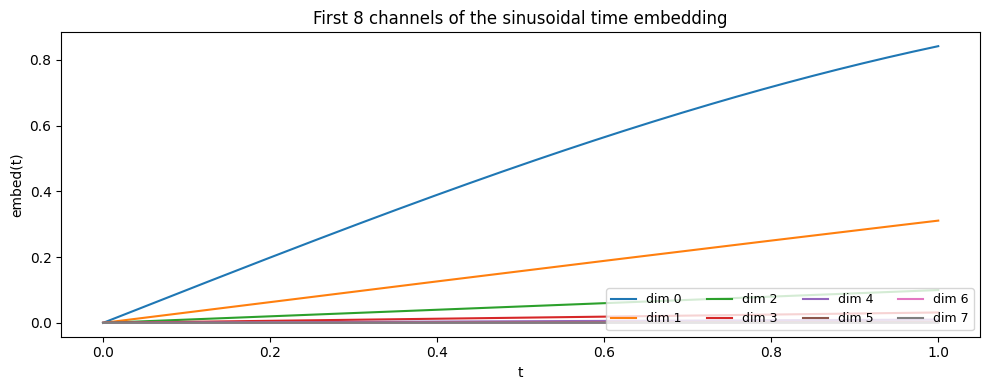

In [40]:
t_grid = torch.linspace(0, 1, 200).unsqueeze(1)
emb    = sinusoidal_embedding(t_grid, dim=16).numpy()

fig, ax = plt.subplots(figsize=(10, 4))
for d in range(8):
    ax.plot(t_grid.squeeze().numpy(), emb[:, d], label=f'dim {d}')
ax.set_xlabel('t'); ax.set_ylabel('embed(t)')
ax.set_title('First 8 channels of the sinusoidal time embedding')
ax.legend(ncol=4, fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()


## 4. The Conditional Vector Field 🧠

This is the heart of the notebook. We need a network that takes

- $x_t$ — the current state along the flow, shape `(B, reco_dim)`
- $t$ — the time, shape `(B, 1)`
- $c$ — the gen-level condition, shape `(B, cond_dim)`

and outputs a velocity of shape `(B, reco_dim)`.

### 🧱 Architecture (the one we'll use)

```
   x_t ─┐
   t   ─┼─► sinusoidal_embedding  ─► concat ─► input_proj  ─► Linear+SiLU  ─┐
   c   ─┘                                                                    │
                                                                             │
                          ┌──────  residual blocks (× n_blocks)  ──────┐
                          │                                             │
                          ▼                                             ▼
                    h  ──► Linear+SiLU ──► Linear+SiLU ──► +h  ────► …
                          │                              ▲
                          └──────────────────────────────┘
                                                                             │
                                                                             ▼
                                                                       output_proj
                                                                       (→ reco_dim)
```

- **`input_proj`** maps `(x_t, time_embed, cond)` concatenated (total dim = `reco_dim + time_dim + cond_dim`) into the `hidden_dim`.
- Each **residual block** is a tiny MLP that is *added* to its input: `h = h + block(h)`. This keeps gradients flowing through deeper networks.
- **`output_proj`** is a single linear layer mapping back to `reco_dim` — no activation on the final layer (we want the velocity to take any real value).

### ✏️ Task 4.1 — Implement `ConditionalVectorField` from scratch

Build **both** `__init__` *and* `forward`.

**Specification**
- `__init__(self, reco_dim=3, cond_dim=6, time_dim=16, hidden_dim=128, n_blocks=3)`
  - `self.time_dim = time_dim`
  - `self.input_proj`: `nn.Sequential(nn.Linear(reco_dim + time_dim + cond_dim, hidden_dim), nn.SiLU())`
  - `self.blocks`: `nn.ModuleList` of `n_blocks` small MLPs, each `Linear → SiLU → Linear → SiLU` with `hidden_dim` in/out
  - `self.output_proj`: `nn.Linear(hidden_dim, reco_dim)`
- `forward(self, x_t, t, cond)`:
  1. `t_emb = sinusoidal_embedding(t, self.time_dim)`
  2. `h = torch.cat([x_t, t_emb, cond], dim=-1)`
  3. `h = self.input_proj(h)`
  4. loop residual blocks: `h = h + block(h)`
  5. return `self.output_proj(h)`

**💡 Hints**
- Use an `nn.ModuleList` (*not* a plain Python list!) so PyTorch registers the residual-block parameters.
- The residual *addition* is what makes the block "residual" — don't forget the `h +`.

**⚠️ Pitfalls**
- If you forget to concat `cond`, your model ignores conditioning and becomes useless (the test catches this).
- If you forget to concat `t_emb`, the loss will plateau far above zero (also caught by the test).


In [41]:
class ConditionalVectorField(nn.Module):
    # Conditional vector field with time embedding and residual blocks.

    def __init__(self, reco_dim=3, cond_dim=6, time_dim=16, hidden_dim=128, n_blocks=3):
        super().__init__()
        self.time_dim = time_dim
        input_dim = reco_dim + time_dim + cond_dim

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
        )
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
                nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            )
            for _ in range(n_blocks)
        ])
        self.output_proj = nn.Linear(hidden_dim, reco_dim)

    def forward(self, x_t, t, cond):
        t_emb = sinusoidal_embedding(t, self.time_dim)
        h = torch.cat([x_t, t_emb, cond], dim=-1)
        h = self.input_proj(h)
        for block in self.blocks:
            h = h + block(h)
        return self.output_proj(h)


#### 🧪 Validate your model

In [42]:
test_conditional_vector_field_model(ConditionalVectorField);


🧪 Testing ConditionalVectorField


TEST SUMMARY — ConditionalVectorField

✅ PASSED (6):
   • Instantiated successfully (18,499 params)
   • Forward output shape matches (batch, reco_dim)
   • Output depends on `cond`
   • Output depends on `t`
   • Output depends on `x`
   • Gradients flow to all parameters

Total: 6/6 tests passed



🚀 Sanity check: build one and count its parameters.

In [43]:
reco_dim = 3
cond_dim = 6

model = ConditionalVectorField(
    reco_dim=reco_dim, cond_dim=cond_dim,
    time_dim=16, hidden_dim=128, n_blocks=3,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

# Forward pass on a tiny batch
x_test = torch.randn(4, reco_dim, device=device)
t_test = torch.rand(4, 1, device=device)
c_test = torch.randn(4, cond_dim, device=device)
out = model(x_test, t_test, c_test)
print(f'Input:  x={tuple(x_test.shape)}, t={tuple(t_test.shape)}, cond={tuple(c_test.shape)}')
print(f'Output: {tuple(out.shape)}')


Model parameters: 102,787
Input:  x=(4, 3), t=(4, 1), cond=(4, 6)
Output: (4, 3)


## 5. The Conditional CFM Loss 📉

Exactly the same recipe as NB1, with one tiny change — the model now also receives the condition:

$$\mathcal{L}_{\text{CFM}}(\theta) = \mathbb{E}_{t,\, z \sim p_{\text{data}}(\text{reco}, \text{gen}),\, x_0 \sim \mathcal{N}(0, I)}\Big[\big\lVert u_\theta(x_t, t,\, \text{gen}) - (x_1 - x_0) \big\rVert^2\Big]$$

with $x_1 = \text{reco}$, $x_t = (1 - t)\, x_0 + t\, x_1$, and $t \sim \text{Unif}[0, 1]$.

### ✏️ Task 5.1 — Implement `conditional_fm_loss(model, reco_batch, gen_batch)`

**Specification**
- **Inputs:** `model` (takes `x, t, cond`), `reco_batch` of shape `(B, reco_dim)`, `gen_batch` of shape `(B, cond_dim)`
- **Returns:** scalar MSE loss

**💡 Hints**
- Same code as NB1's `flow_matching_loss`, but pass `gen_batch` as the third arg to `model`.
- `torch.randn_like(reco_batch)` gives noise with the right shape and device.
- `t` is per-sample: shape `(batch, 1)`.


In [44]:
def conditional_fm_loss(model, reco_batch, gen_batch):
    batch_size = reco_batch.shape[0]
    x0 = torch.randn_like(reco_batch)
    t = torch.rand(batch_size, 1, device=reco_batch.device)
    x_t = (1 - t) * x0 + t * reco_batch
    target = reco_batch - x0
    predicted = model(x_t, t, gen_batch)
    return torch.mean((predicted - target) ** 2)


In [45]:
test_conditional_fm_loss(conditional_fm_loss, model_cls=ConditionalVectorField);


🧪 Testing conditional_fm_loss


TEST SUMMARY — conditional_fm_loss

✅ PASSED (3):
   • Scalar, finite, non-negative (got 2.0331)
   • Zero-model baseline ≈ 2.0 (got 1.98)
   • Loss is differentiable through the model

Total: 3/3 tests passed



## 6. Training Loop 🏋️

Nothing exotic — shuffle, mini-batch, gradient step. Same as any PyTorch training loop.

### ✏️ Task 6.1 — Implement `train_conditional_model`

**Specification**
```python
train_conditional_model(model, reco_train, gen_train, reco_val, gen_val,
                        n_epochs=80, batch_size=512, lr=1e-3)
    -> (train_losses, val_losses)
```
- For each of `n_epochs` epochs:
  1. Shuffle the training indices with `torch.randperm`
  2. Iterate over mini-batches
  3. For each batch: compute `conditional_fm_loss`, backprop, optimizer step
  4. At the end of the epoch, compute a **val loss** (on a subsample of val is fine — 5000 points is plenty)
- Print progress every 10 epochs
- Return `(train_losses, val_losses)` — one entry per epoch, each

**💡 Hints**
- Use `torch.optim.Adam(model.parameters(), lr=lr)`
- `for i in range(0, n_train, batch_size): idx = indices[i:i+batch_size]`
- Wrap the val loss in `torch.no_grad()` and put the model in `eval()` mode for that step


In [46]:
def train_conditional_model(model, reco_train, gen_train, reco_val, gen_val,
                            n_epochs=80, batch_size=512, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    n_train = reco_train.shape[0]
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        indices = torch.randperm(n_train, device=reco_train.device)
        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, n_train, batch_size):
            idx = indices[i:i + batch_size]
            reco_batch = reco_train[idx]
            gen_batch  = gen_train[idx]

            optimizer.zero_grad()
            loss = conditional_fm_loss(model, reco_batch, gen_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        train_losses.append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            val_subset = min(5000, reco_val.shape[0])
            val_losses.append(
                conditional_fm_loss(model, reco_val[:val_subset], gen_val[:val_subset]).item()
            )

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d}/{n_epochs} | train {train_losses[-1]:.4f} | val {val_losses[-1]:.4f}')

    return train_losses, val_losses


In [47]:
test_train_conditional_model(train_conditional_model, model_cls=ConditionalVectorField);


🧪 Testing train_conditional_model

Epoch  10/25 | train 0.6501 | val 0.6609
Epoch  20/25 | train 0.5796 | val 0.5829

TEST SUMMARY — train_conditional_model

✅ PASSED (1):
   • Loss decreases: 1.933 → 0.628

Total: 1/1 tests passed



### 🚀 Train on CMS jets

We train for 80 epochs with batch size 512 — that's about **4 minutes on CPU**, a few seconds on GPU. Take a coffee break or watch the loss curve. ☕

In [49]:
print('Starting training...')
train_losses, val_losses = train_conditional_model(
    model,
    reco_train_t, gen_train_t,
    reco_val_t,   gen_val_t,
    n_epochs=80, batch_size=2048, lr=1e-3,
)
print('Training complete!')


Starting training...
Epoch  10/80 | train 1.0455 | val 1.0570
Epoch  20/80 | train 1.0424 | val 1.0492
Epoch  30/80 | train 1.0430 | val 1.0421
Epoch  40/80 | train 1.0435 | val 1.0441
Epoch  50/80 | train 1.0408 | val 1.0370
Epoch  60/80 | train 1.0393 | val 1.0145
Epoch  70/80 | train 1.0417 | val 1.0135
Epoch  80/80 | train 1.0393 | val 1.0435
Training complete!


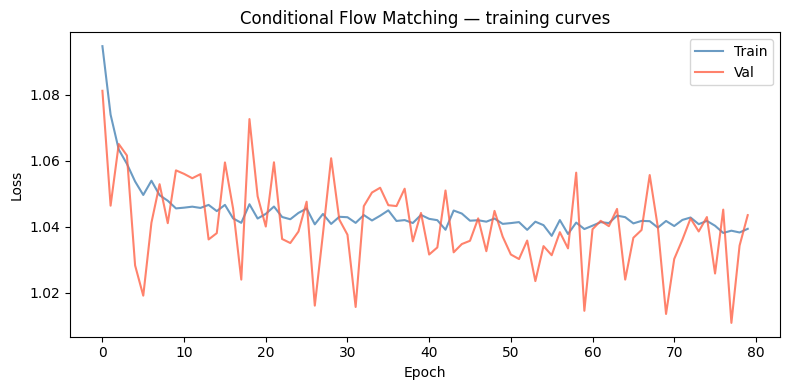

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train', color='steelblue', alpha=0.8)
ax.plot(val_losses,   label='Val',   color='tomato',    alpha=0.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Conditional Flow Matching — training curves')
ax.legend(); plt.tight_layout(); plt.show()


## 7. Conditional Generation 🎬

The flow-matching ODE is exactly the same as NB1, but now the learned vector field takes the condition `cond` as an extra input at every step:

$$\frac{d x}{d t} = u_\theta(x, t, \text{gen})$$

To avoid OOM when generating for the full 80k-jet validation set, we process the data in chunks.

### ✏️ Task 7.1 — Implement `generate_reco`

**Specification**
```python
@torch.no_grad()
generate_reco(model, gen_cond, n_steps=100, batch_size=4096) -> (N, reco_dim) tensor
```
- Integrate the ODE from `t=0` to `t=1` using Euler steps of size `h = 1/n_steps`.
- Process `gen_cond` in chunks of at most `batch_size` rows.
- At each step: `x = x + h * model(x, t_tensor, cond_batch)`
- The starting point is pure noise: `torch.randn(chunk_size, reco_dim, device=gen_cond.device)`.

**💡 Hints**
- Infer `reco_dim` from `model.output_proj.out_features` — saves an extra argument.
- Use `torch.full((chunk_size, 1), step * h, device=...)` for the time tensor.

**⚠️ Pitfall** — Remember to move the *final* samples onto CPU (or return them on the same device as `gen_cond` — just be consistent). In the reference solution we append `.cpu()` at the end.


In [51]:
@torch.no_grad()
def generate_reco(model, gen_cond, n_steps=100, batch_size=4096):
    model.eval()
    reco_dim = model.output_proj.out_features
    h = 1.0 / n_steps
    all_samples = []

    for start in range(0, gen_cond.shape[0], batch_size):
        cond_chunk = gen_cond[start:start + batch_size]
        n = cond_chunk.shape[0]
        x = torch.randn(n, reco_dim, device=gen_cond.device)
        for step in range(n_steps):
            t = torch.full((n, 1), step * h, device=gen_cond.device)
            x = x + h * model(x, t, cond_chunk)
        all_samples.append(x)

    return torch.cat(all_samples, dim=0)


In [52]:
test_generate_reco(generate_reco, model_cls=ConditionalVectorField);


🧪 Testing generate_reco


TEST SUMMARY — generate_reco

✅ PASSED (4):
   • Output shape is (N, reco_dim)
   • All generated values are finite
   • Samples are stochastic (start from fresh noise)
   • Handles arbitrary batch sizes (130 samples)

Total: 4/4 tests passed



### 🚀 Generate reco samples for the full val set, then compare

Generating samples for the validation set...
Generated: (80000, 3)


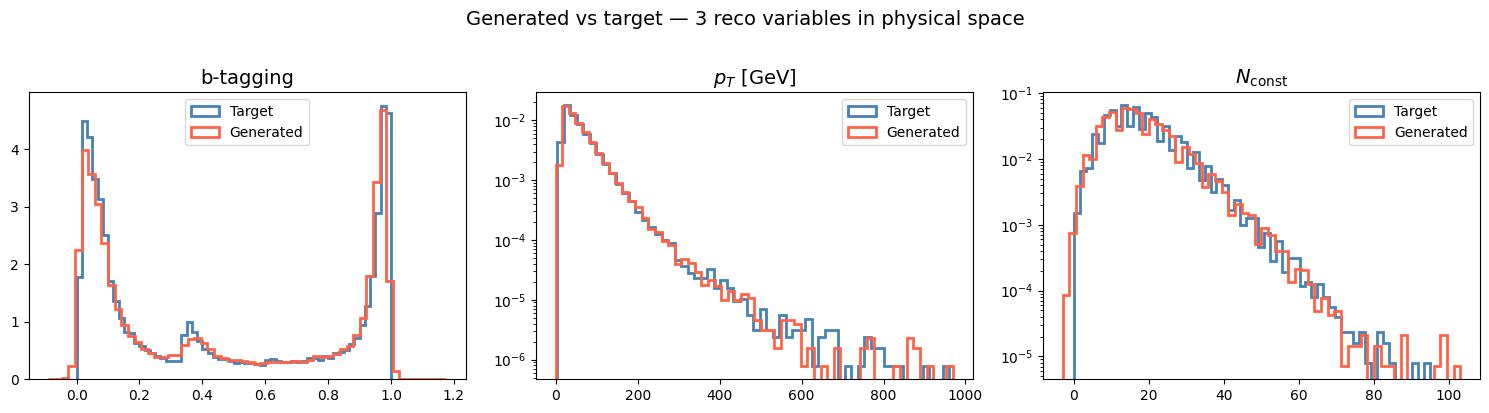

In [53]:
print('Generating samples for the validation set...')
generated_scaled = generate_reco(model, gen_val_t, n_steps=100).cpu().numpy()
print(f'Generated: {generated_scaled.shape}')

# Inverse-transform both generated and target back to physical space
generated_phys, gen_val_phys = preprocessor.inverse_transform(generated_scaled, gen_val)
target_phys,    _            = preprocessor.inverse_transform(reco_val,         gen_val)

feature_names = ['b-tagging', r'$p_T$ [GeV]', r'$N_{\mathrm{const}}$']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, name) in enumerate(zip(axes, feature_names)):
    ax.hist(target_phys[:, i],    bins=60, histtype='step', lw=2, color='steelblue', label='Target',    density=True)
    ax.hist(generated_phys[:, i], bins=60, histtype='step', lw=2, color='tomato',    label='Generated', density=True)
    ax.set_title(name, fontsize=14); ax.legend(fontsize=10)
    if i > 0:
        ax.set_yscale('log')
plt.suptitle('Generated vs target — 3 reco variables in physical space', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


Not bad! The gross features of each distribution are recovered. The finer comparison (ratio plots, Wasserstein distances, ROC curves) is the subject of Notebook 3. 📏

## 8. 🎇 Does Conditioning Actually Help?

Quick experiment: train an **unconditional** baseline that ignores `gen` and learns only the **marginal** $p(\text{reco})$, then compare it to our conditional model on a diagnostic where the difference is unambiguous.

### 🎁 Provided: training a baseline (no coding — just run)

We train a tiny unconditional baseline for 30 epochs (~1 min) by passing **zeros** as the condition. No need to re-implement the network.

In [54]:
print('Training an unconditional baseline (cond fed as zeros)...')
baseline = ConditionalVectorField(
    reco_dim=reco_dim, cond_dim=cond_dim,
    time_dim=16, hidden_dim=128, n_blocks=3,
).to(device)

# Replace gen with a zero vector of the same shape — the model then has
# no useful signal and collapses to learning the marginal p(reco).
zero_train = torch.zeros_like(gen_train_t)
zero_val   = torch.zeros_like(gen_val_t)

_ = train_conditional_model(
    baseline, reco_train_t, zero_train,
    reco_val_t, zero_val,
    n_epochs=30, batch_size=2048, lr=1e-3,
)


Training an unconditional baseline (cond fed as zeros)...
Epoch  10/30 | train 1.4745 | val 1.4708
Epoch  20/30 | train 1.4741 | val 1.4854
Epoch  30/30 | train 1.4691 | val 1.5220


### 1D marginal overlays (the usual first look)

First, generate from both models and compare the 1D marginal distributions of the three reco features.

Generating from both models...


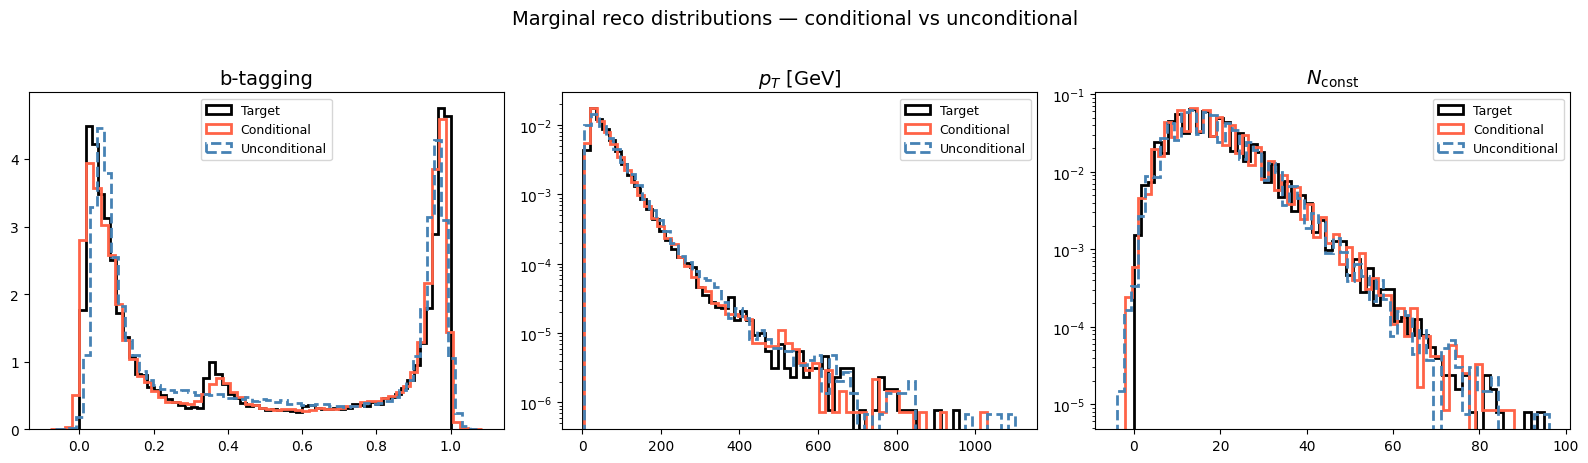

In [55]:
print('Generating from both models...')
gen_conditional   = generate_reco(model,    gen_val_t, n_steps=100).cpu().numpy()
gen_unconditional = generate_reco(baseline, zero_val,  n_steps=100).cpu().numpy()

cond_phys, _    = preprocessor.inverse_transform(gen_conditional,   gen_val)
uncond_phys, _  = preprocessor.inverse_transform(gen_unconditional, gen_val)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, (ax, name) in enumerate(zip(axes, feature_names)):
    ax.hist(target_phys[:, i], bins=60, histtype='step', lw=2, color='black',     label='Target',             density=True)
    ax.hist(cond_phys[:, i],   bins=60, histtype='step', lw=2, color='tomato',    label='Conditional',        density=True)
    ax.hist(uncond_phys[:, i], bins=60, histtype='step', lw=2, color='steelblue', label='Unconditional',      density=True, linestyle='--')
    ax.set_title(name, fontsize=14); ax.legend(fontsize=9)
    if i > 0:
        ax.set_yscale('log')
plt.suptitle('Marginal reco distributions — conditional vs unconditional', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


💭 **A subtle point.** The three marginals often look *very* similar between the two models. That doesn't mean conditioning doesn't matter — it means marginal histograms are a **weak diagnostic**. Two things to be aware of:

1. Both models try to match the **same** $p(\text{reco})$ marginal, so a well-trained unconditional model *should* get it right on average.
2. The $p_T$ distribution in particular is leaky: our preprocessor uses the ratio `reco_pt / gen_pt`, and the inverse transform multiplies by the true `gen_pt` — so even the unconditional samples inherit the right `gen_pt` spectrum through the post-processing. 🙈

We need a diagnostic that looks at **conditional** behaviour, not marginals. ⤵️

### 🏷️ The cleaner test: **b-tagging score, split by jet flavour**

A much cleaner probe is the **b-tagging discriminator, conditioned on true jet flavour**. We know physically that:

- **bottom** jets (flavour = 2) should peak at **high** btag scores
- **light** jets (flavour = 0) should peak at **low** btag scores
- **charm** jets (flavour = 1) should sit somewhere in between

The conditional model sees `flavour` in its `cond` vector, so it *can* produce different btag distributions per flavour. The unconditional model sees nothing — it must generate the **same marginal btag distribution** regardless of the true flavour.

Let's look.

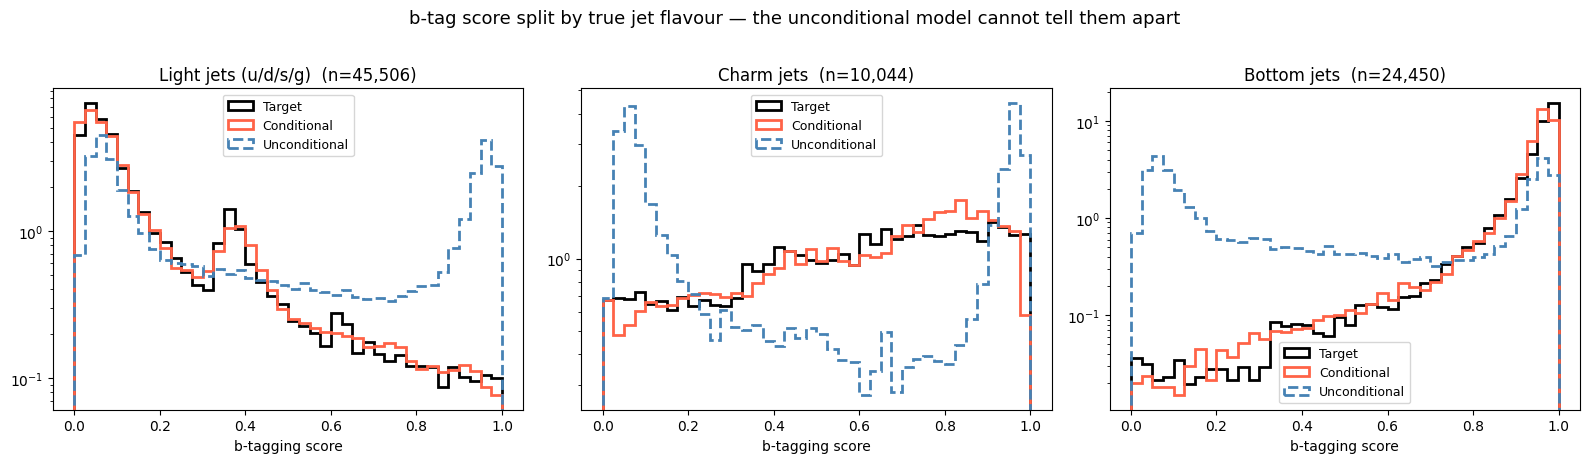

In [56]:
# Flavour is col 4 of gen_val_phys (untouched by preprocessing: 0=light, 1=charm, 2=bottom)
flavour = gen_val_phys[:, 4].astype(int)

flav_labels = {0: 'Light jets (u/d/s/g)', 1: 'Charm jets', 2: 'Bottom jets'}
bins = np.linspace(0, 1, 41)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, flav in zip(axes, [0, 1, 2]):
    mask = (flavour == flav)
    ax.hist(target_phys[mask, 0], bins=bins, histtype='step', lw=2,
            color='black',     label='Target',             density=True)
    ax.hist(cond_phys[mask, 0],   bins=bins, histtype='step', lw=2,
            color='tomato',    label='Conditional',        density=True)
    ax.hist(uncond_phys[mask, 0], bins=bins, histtype='step', lw=2,
            color='steelblue', label='Unconditional',      density=True, linestyle='--')
    ax.set_title(f'{flav_labels[flav]}  (n={mask.sum():,})', fontsize=12)
    ax.set_xlabel('b-tagging score'); ax.set_yscale('log')
    ax.legend(fontsize=9)
plt.suptitle('b-tag score split by true jet flavour — the unconditional model cannot tell them apart', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### 📝 What to look for

- The **target** (black) shows a clear flavour-dependent structure: light jets cluster at low btag, bottom jets at high btag, charm in between.
- The **conditional model** (tomato) tracks the black curve in *each* panel — it has learned $p(\text{btag} \mid \text{flavour}, \ldots)$ per flavour class.
- The **unconditional model** (blue dashed) is the **same curve in all three panels** — it only knows the flavour-averaged btag marginal, so it mis-tags everything.

That mismatch is exactly the kind of failure mode that would ruin a downstream b-tagging analysis. Conditioning is what makes the simulator usable for physics. 🎯

## 9. Final Comprehensive Test ✅

Run the full test suite one more time before saving the model for Notebook 3.

In [57]:
run_all_tests_nb2(
    sinusoidal_embedding=sinusoidal_embedding,
    model_cls=ConditionalVectorField,
    conditional_fm_loss=conditional_fm_loss,
    train_conditional_model=train_conditional_model,
    generate_reco=generate_reco,
);



🚀 Running all Notebook 2 tests

🧪 Testing sinusoidal_embedding


TEST SUMMARY — sinusoidal_embedding

✅ PASSED (4):
   • Output shape is (batch, dim)
   • Values bounded in [-1, 1]
   • Embedding depends on t
   • Works for a range of even dims

Total: 4/4 tests passed

🧪 Testing ConditionalVectorField


TEST SUMMARY — ConditionalVectorField

✅ PASSED (6):
   • Instantiated successfully (18,499 params)
   • Forward output shape matches (batch, reco_dim)
   • Output depends on `cond`
   • Output depends on `t`
   • Output depends on `x`
   • Gradients flow to all parameters

Total: 6/6 tests passed

🧪 Testing conditional_fm_loss


TEST SUMMARY — conditional_fm_loss

✅ PASSED (3):
   • Scalar, finite, non-negative (got 2.0817)
   • Zero-model baseline ≈ 2.0 (got 1.98)
   • Loss is differentiable through the model

Total: 3/3 tests passed

🧪 Testing train_conditional_model

Epoch  10/25 | train 0.6501 | val 0.6609
Epoch  20/25 | train 0.5796 | val 0.5829

TEST SUMMARY — train_conditional

## 💾 Save the Model for Notebook 3

Notebook 3 picks up from here: it loads the trained model, generates samples, and builds a scorecard of evaluation metrics (Wasserstein distances, ROC curves, classifier two-sample tests) — then challenges you to **improve** the numbers. 🏆

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'reco_dim':   reco_dim,
        'cond_dim':   cond_dim,
        'time_dim':   16,
        'hidden_dim': 128,
        'n_blocks':   3,
    },
    'preprocessor': preprocessor,
    'train_losses': train_losses,
    'val_losses':   val_losses,
}, 'model_nb2.pt')
print('✅ Model saved to model_nb2.pt — ready for Notebook 3.')


## 🏁 Summary

In this notebook you:

1. Loaded and explored the **CMS jet dataset** (400k jet pairs, 3 reco vars + 6 gen vars).
2. Used a ready-made **Preprocessor** (`pt_ratio`, dequantisation, standard scaling) — the unglamorous plumbing, handed to you.
3. Implemented a **sinusoidal time embedding** to give the network a richer representation of time.
4. Built a **`ConditionalVectorField`** network from scratch — input projection, residual blocks, output projection — with time + condition wired into the input.
5. Wrote a **conditional CFM loss**, a **training loop**, and a **batched generation function**.
6. Trained a real fast detector simulator in well under 5 minutes of CPU time 🚀.
7. Compared against an **unconditional baseline** and saw concretely *why* the conditioning signal matters.

### ➡️ Next up

**Notebook 3** takes this checkpoint and asks: *how good is it, really?* You'll compute rigorous evaluation metrics (Wasserstein distances, classifier two-sample tests, ROC-based detector-physics checks) on a shared scorecard — and then try to **beat** the baseline with your own improvements (deeper model? more epochs? Heun sampler? better preprocessing?). 🏆
